# Making Linear Models Nonlinear Via Kernels

Explanation via example(s):

We might have data in 2D that seems nonlinear, but we can map into higher dimensional space and fit a linear model there.

EX: Suppose we have two features $x_1,x_2$, and are attempting to fit something that is nonlinear. We need to construct a map $\phi$ taking $x=[x_1,x_2]$ to $x = [1,x_1,x_1^2,,x_1^2,x_2,x_2^2,x_1x_2]$.

We'll show the only thing we'll need is dot products!

### A bit about dot products

Lets think of this as a row vector times a column vector (with output a scalar).

If we have points $x=[x_1,x_2],z=[z_1,z_2]$, In our original space $xz^T = x_1z_1+x_2z_2$. But in the higher dimensional space, $xz^T$ needs a ton of arithmetic operations for calculation.

**Kernels** allow you compute $\phi(x)\phi(z)^T$ without ever computing the maps.

Define $k(x,z) = (1+xz^T)^2$, which takes $5$ total operations. See that
$$
k(x,z) = (1+x_1z_1+x_2z_2)^2 = 1 + 2x_1z_1 + 2x_2z_2 + 2x_1z_1x_2z_2 + x_1^2z_1^2 + z_2^2z_2^2 = stuff
$$

## Linear regression using only dot products

In Least Squares problems, we have $\min \|y-X\theta\|^2$ given matrix $X$ where the rows are the given data points.

Here, $XX^T$ contains dot products. If $X$ has independent columns, then $\theta = X^T[\alpha]$ for some $\alpha$.

Then, $\min \|y-X\theta\|^2 = \min\|y-XX^T\alpha\|^2$

The 'Kernel Trick' is to replace $XX^T$ with (1+XX^T)^2 = K$.

So we must now solve $\min \|y-K\alpha\|^2$.
****

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

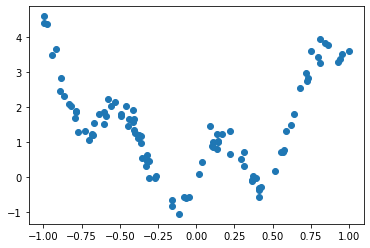

In [2]:
m = 100
x = -1 + 2*np.random.rand(m)
y = np.sin(10*x)+4*x**2+0.2*np.random.randn(m)

plt.scatter(x,y)

In [3]:
x = x.reshape(-1,1) # make colvec

In [9]:
# apply a kernel to the matrix with the dot products.
d=2
K = (1+x.dot(x.T))**d

alpha = np.linalg.lstsq(K,y,rcond=None)[0]



In [8]:
#plot the fitted model
m_plot = 100
x_plot = np.linspace(-1,1,m_plot).reshape(-1,1) #make column
K_plot = (1+x_plot.dot(x.T))**d
y_plot = K_plot.dot(x)

#plt.scatter() incomplete

****
## Gaussian Kernel

$K(x,z) = e^{\gamma \| x-z\|^2}$ for some parameter $\gamma$ we choose.

We will show that $K(x,z) = \phi(x)\phi(z)^T$, where $\phi$ takes our points into an infinite-dimensional space.

example: x,z are 1-dimensional vectors

$k(x,z) = e^{-\gamma (x-z)^2}=e^{-\gamma(x^2+z^2-2xz)}= e^{-\gamma x^2}e^{-\gamma z^2}e^{-\gamma 2xz}$

Using Taylor Series : $e^x = 1 +x + x^2/2 +x^3/6 + \ldots$:

$k(x,z) = e^{-\gamma x^2}e^{-\gamma z^2}e^{-\gamma 2xz}= e^{-\gamma x^2}e^{-\gamma z^2}(1+2xz+(2xz)^2/2+\ldots)=$

dot product of two infinite dimensional vectors...
****

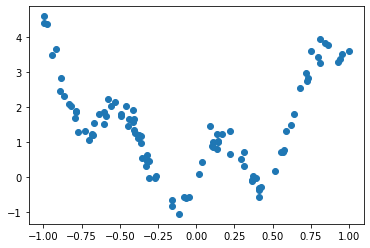

In [10]:
plt.scatter(x,y)

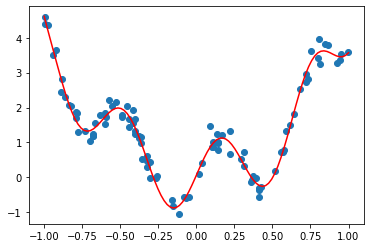

In [19]:
#step 1: distance matrix

from sklearn.metrics import pairwise_distances

dist = pairwise_distances(x)

#step 2: apply the Gaussian Kernel and gamma
gamma = 1
K = np.exp(-gamma*dist**2)

#solve least squares problem

alpha = np.linalg.lstsq(K,y,rcond = None)[0]

#plot fitted model

m_plot = 100

x_plot = np.linspace(-1,1,m_plot).reshape(-1,1) #make column

dist_plot = pairwise_distances(x,x_plot).T

K_plot = np.exp(-gamma*dist_plot**2)

y_plot = K_plot.dot(alpha)

plt.plot(x_plot,y_plot, color = 'red')
plt.scatter(x,y)

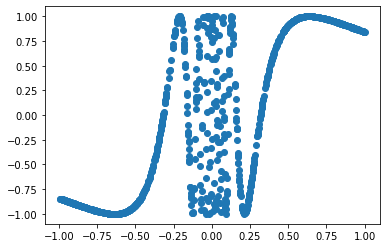

In [21]:
m = 1000
x = -1 + 2*np.random.rand(m)
y = np.sin(1/x)
plt.scatter(x,y)

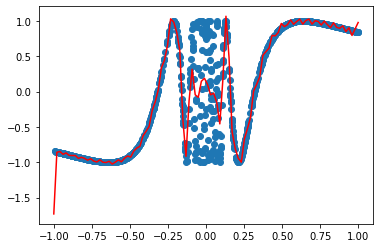

In [27]:
x = x.reshape(-1,1)

#step 1: distance matrix

from sklearn.metrics import pairwise_distances

dist = pairwise_distances(x)

#step 2: apply the Gaussian Kernel and gamma
gamma = 1e2
K = np.exp(-gamma*dist**2)

#solve least squares problem

alpha = np.linalg.lstsq(K,y,rcond = None)[0]

#plot fitted model

m_plot = 100

x_plot = np.linspace(-1,1,m_plot).reshape(-1,1) #make column

dist_plot = pairwise_distances(x,x_plot).T

K_plot = np.exp(-gamma*dist_plot**2)

y_plot = K_plot.dot(alpha)

plt.plot(x_plot,y_plot, color = 'red')
plt.scatter(x,y)